# DiffPIR / DPS / Plug-and-Play comparison

This notebook is a unified playground for comparing:

- DiffPIR
- DPS variants (`DPS_y0`, `DPS_yt`)
- Plug-and-play methods with other priors (e.g. DRUNet)

across the three tasks:

- Super-resolution (SISR)
- Deblurring
- Inpainting

In [1]:
import os
from pathlib import Path
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt

from experiments.common import MethodConfig, RunResult, run_experiment, load_image_paths
from experiments import pnp_priors
from experiments import sr_methods, deblur_methods, inpaint_methods


In [2]:
# Registry of available per-image methods for each task.

def get_sr_methods():
    return {
        "diffpir": sr_methods.run_diffpir_sr,
        "dps_y0": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_yt"),
        "pnp_drunet": sr_methods.run_pnp_sr,
        "pnp_gaussian": sr_methods.run_pnp_sr,
    }


def get_deblur_methods():
    return {
        "diffpir": deblur_methods.run_diffpir_deblur,
        "dps_y0": lambda img, cfg: deblur_methods.run_dps_deblur(
            img, cfg, mode="DPS_y0"
        ),
        "dps_yt": lambda img, cfg: deblur_methods.run_dps_deblur(
            img, cfg, mode="DPS_yt"
        ),
        "pnp_drunet": deblur_methods.run_pnp_deblur,
        "pnp_gaussian": deblur_methods.run_pnp_deblur,
    }


def get_inpaint_methods():
    return {
        "diffpir": inpaint_methods.run_diffpir_inpaint,
        "dps_y0": lambda img, cfg: inpaint_methods.run_dps_inpaint(
            img, cfg, mode="DPS_y0"
        ),
        "dps_yt": lambda img, cfg: inpaint_methods.run_dps_inpaint(
            img, cfg, mode="DPS_yt"
        ),
        "pnp_drunet": inpaint_methods.run_pnp_inpaint,
        "pnp_gaussian": inpaint_methods.run_pnp_inpaint,
        "pnp_diffbir": inpaint_methods.run_pnp_inpaint,
    }


METHOD_REGISTRY = {
    "sr": get_sr_methods(),
    "deblur": get_deblur_methods(),
    "inpaint": get_inpaint_methods(),
}


def _default_method_config(task: str, name: str) -> MethodConfig:
    """Create a simple MethodConfig for a given task/method name."""

    if name.startswith("dps_"):
        generate_mode = name.upper()  # "DPS_Y0" / "DPS_YT" variants
    elif name == "diffpir":
        generate_mode = "DiffPIR"
    else:
        generate_mode = name  # e.g. "pnp_drunet"

    return MethodConfig.load_from_yaml(
        os.path.join("configs", f"{task}.yaml"),
        name
    )


def compare_task(
    task: str,
    testset_root: str,
    methods: List[str],
) -> Dict[str, RunResult]:
    """Run all selected methods for a given task over a dataset.

    Returns a dict mapping method name -> RunResult.
    """

    image_paths = load_image_paths(testset_root)
    task_methods = METHOD_REGISTRY[task]
    results: Dict[str, RunResult] = {}

    for name in methods:
        if name not in task_methods:
            raise ValueError(f"Unknown method '{name}' for task '{task}'")
        method_fn = task_methods[name]
        cfg = _default_method_config(task=task, name=name)
        print(cfg)
        run_result = run_experiment(
            method_config=cfg,
            image_paths=[image_paths[0]], # image_paths
            method_fn=method_fn,
            output_root=None,
        )
        results[name] = run_result
    return results


def plot_metric_bar(results: Dict[str, RunResult], metric: str = "average_psnr", title: str = ""):
    """Plot a bar chart of a given aggregate metric for each method."""

    methods = list(results.keys())
    values = [float(getattr(results[m], metric)) for m in methods]

    plt.figure(figsize=(6, 4))
    plt.bar(methods, values)
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# show resulting images
def show_results(results: Dict[str, RunResult], max_images: int = 5, action: str = "<Method Name>") -> None:
    """Display results as a grid: one row per image, one column per method.
    The plot title now includes the action we are doing.
    """

    first_run = next(iter(results.values()))
    all_img_names = list(first_run.image_results.keys())
    img_names = all_img_names[:max_images]

    n_rows = len(img_names)
    n_cols = len(results) + 1  # +1 for ground-truth column

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    full_title = f"{action} Results" if action else "Results"
    fig.suptitle(full_title, fontsize=16, fontweight="bold", y=1.02)

    for row, img_name in enumerate(img_names):
        # --- Ground-truth column ---
        gt_path = first_run.image_results[img_name].image_path
        ax_gt = axes[row, 0]
        ax_gt.imshow(plt.imread(gt_path))
        print(np.min(plt.imread(gt_path)), np.max(plt.imread(gt_path)))
        ax_gt.set_ylabel(img_name, fontsize=8, rotation=0, labelpad=60, va="center")
        # Method name only on the first row to avoid repetition
        ax_gt.set_title("Ground Truth" if row == 0 else "", fontsize=10, fontweight="bold")
        ax_gt.axis("off")

        # --- One column per method ---
        for col, (method_name, run_result) in enumerate(results.items(), start=1):
            ax = axes[row, col]
            img_result = run_result.image_results.get(img_name)

            if img_result is None:
                ax.text(0.5, 0.5, "No result", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)
                ax.axis("off")
                continue

            if img_result.output_path and os.path.exists(img_result.output_path):
                ax.imshow(plt.imread(img_result.output_path))
            else:
                ax.text(
                    0.5, 0.5,
                    f"Image not found\n{img_result.output_path}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=7,
                )

            # Method name only on the first row; metrics on every row
            metrics = f"PSNR: {img_result.psnr:.2f} dB"
            if img_result.lpips is not None:
                metrics += f"  LPIPS: {img_result.lpips:.4f}"
            if row == 0:
                ax.set_title(f"{method_name}\n{metrics}", fontsize=9, fontweight="bold")
            else:
                ax.set_title(metrics, fontsize=8)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
# # Hyper parameters tuning
# # Let's try to find best lambda for deblurring
# def best_lambda_deblur():
#     # Load the deblur config
#     config = MethodConfig.load_from_yaml(os.path.join("configs", "deblur.yaml"))
#     best_lambda = None
#     best_psnr = 0
#     # Run the deblur experiment for a range of lambdas
#     for lambda_ in np.arange(1, 5):
#         deblur_results = compare_task(
#             task="deblur",
#             testset_root="testsets/demo_test",
#             methods=["diffpir"],
#             sf=1,
#             lambda_=lambda_,
#         )
#         # Get the average PSNR of the deblur results
#         average_psnr = deblur_results["diffpir"].average_psnr
#         print(f"Lambda: {lambda_}, Average PSNR: {average_psnr}")
#         if average_psnr > best_psnr:
#             best_psnr = average_psnr
#             best_lambda = lambda_
#     print(f"Best lambda: {best_lambda}, Best PSNR: {best_psnr}")
#     return best_lambda, best_psnr

# best_lambda_deblur()

In [ ]:
# Deblurring comparison
deblur_results = compare_task(
    task="deblur",
    testset_root="testsets/demo_test",
    methods=["diffpir", "dps_y0", "dps_yt", "pnp_drunet", "pnp_gaussian"], 
)
plot_metric_bar(deblur_results, metric="average_psnr", title="Deblur: Average PSNR")
show_results(deblur_results, action="Deblur")

Loading dps_y0 from configs\deblur.yaml
MethodConfig(task='deblur', generate_mode='DPS_y0', lambda_=0.1, zeta=0.0, sf=1, extra={'name': 'dps_y0', 'seed': 42, 'noise_level_img': 0.05, 'noise_level_model': 'noise_level_img', 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'batch_size': 16, 'save_L': True, 'save_E': True, 'output_root': 'outputs', 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'use_DIY_kernel': True, 'blur_mode': 'Gaussian', 'kernel_size': 61, 'kernel_std': 3.0})
Using device: cuda
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[2026-03-14 01:08:31,629][diffpir_deblur.69037][INFO] Loading ground-truth image from testsets/demo_test\69037.png
[2026-03-14 01:08:31,635][diffpir_deblur.69037][INFO] Blur kernel: mode=Gaussian | kernel_size=61 | kernel_std≈3.000
[2026-03-14 01:08:31,637][diffpir_deblur.69037][INFO] Applying blur and AWGN (σ≈0.050

Loading model from: c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\lpips\weights\v0.1\vgg.pth


[2026-03-14 01:08:32,424][diffpir_deblur.69037][INFO] Starting DPS reverse diffusion (1000 steps)
DPS Deblurring: 406it [01:31,  4.46it/s]


KeyboardInterrupt: 

[2026-03-13 15:51:38,512][diffpir_sr.69037][INFO] Starting DiffPIR SR | img=69037 | sf=4 | lambda=1.000 | zeta=0.100 | noise=0.0500 | model=diffusion_ffhq_10m | mode=blur


Loading diffpir from configs/sr.yaml
MethodConfig(task='sr', generate_mode='DiffPIR', lambda_=1.0, zeta=0.1, sf=4, extra={'seed': 42, 'noise_level_img': 0.05, 'noise_level_model': 0.05, 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'iter_num': 100, 'iter_num_U': 1, 'batch_size': 16, 'save_L': True, 'save_E': True, 'sub_1_analytic': True, 'log_process': False, 'ddim_sample': False, 'model_output_type': 'pred_xstart', 'skip_type': 'quad', 'eta': 0.0, 'guidance_scale': 1.0, 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'beta_start': 0.0001, 'beta_end': 0.02, 'sr_mode': 'blur', 'classical_degradation': False, 'inIter': 1, 'gamma': 0.01})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-13 15:51:39,446][diffpir_sr.69037][INFO] Loaded SR kernel | classical=False | sf=4 | shape=(25, 25)
[2026-03-13 15:51:39,446][diffpir_sr.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-13 15:51:39,453][diffpir_sr.69037][INFO] SR observation: mode=blur | sf=4 | LR size=(64, 64) | noise=0.0500
[2026-03-13 15:51:39,467][diffpir_sr.69037][INFO] Starting reverse diffusion (100 steps, skip_type=quad)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


DiffPIR SR x4: 100%|██████████| 100/100 [01:07<00:00,  1.48it/s]
[2026-03-13 15:52:47,242][diffpir_sr.69037][INFO] Reverse diffusion finished for 69037
[2026-03-13 15:52:47,382][diffpir_sr.69037][INFO] Results | img=69037 | PSNR=23.471 dB | PSNR-Y=26.369 dB | LPIPS=0.4434
[2026-03-13 15:52:47,391][diffpir_sr.69037][INFO] Saved SR image to outputs/diffpir_sr/69037_x4_diffpir.png
[2026-03-13 15:52:47,392][diffpir_sr.69037][INFO] Saved LR image to outputs/diffpir_sr/69037_x4_LR.png
[2026-03-13 15:52:47,418][pnp_sr.69037][INFO] Starting PnP SR | img=69037 | sf=4 | denoiser=drunet | iters=100 | mode=blur | noise=0.0500
[2026-03-13 15:52:47,419][pnp_sr.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-13 15:52:47,427][pnp_sr.69037][INFO] Loaded SR kernel | classical=False | sf=4 | shape=(25, 25)
[2026-03-13 15:52:47,437][pnp_sr.69037][INFO] SR observation: mode=blur | sf=4 | LR size=(64, 64) | noise=0.0500


...

Loading pnp_gaussian from configs/sr.yaml
MethodConfig(task='sr', generate_mode='pnp_gaussian', lambda_=1.0, zeta=0.0, sf=4, extra={'name': 'pnp_gaussian', 'noise_level_img': 0.05, 'sr_mode': 'blur', 'classical_degradation': False, 'inIter': 1, 'gamma': 0.01, 'denoiser': 'gaussian', 'num_iters': 100, 'denoiser_sigma': 0.05, 'gaussian_kernel_size': 5, 'gaussian_sigma': 0.5, 'calc_LPIPS': True, 'save_L': True, 'save_E': True, 'clamp': True, 'output_root': 'outputs'})


PnP SR x4: 100%|██████████| 100/100 [00:00<00:00, 243.94it/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-13 15:53:31,011][pnp_sr.69037][INFO] Results | img=69037 | PSNR=24.665 dB | PSNR-Y=27.075 dB | LPIPS=0.5167
[2026-03-13 15:53:31,014][pnp_sr.69037][INFO] Saved SR image to outputs/pnp_sr/69037_x4_pnp_gaussian.png
[2026-03-13 15:53:31,015][pnp_sr.69037][INFO] Saved LR image to outputs/pnp_sr/69037_x4_LR.png


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


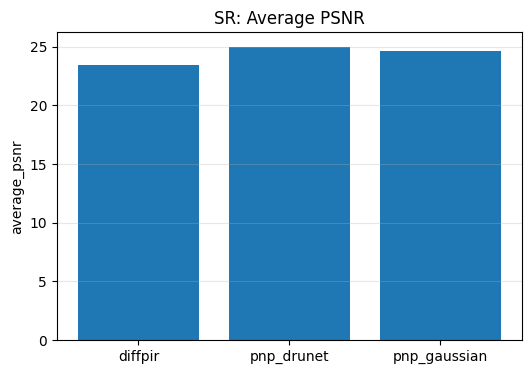

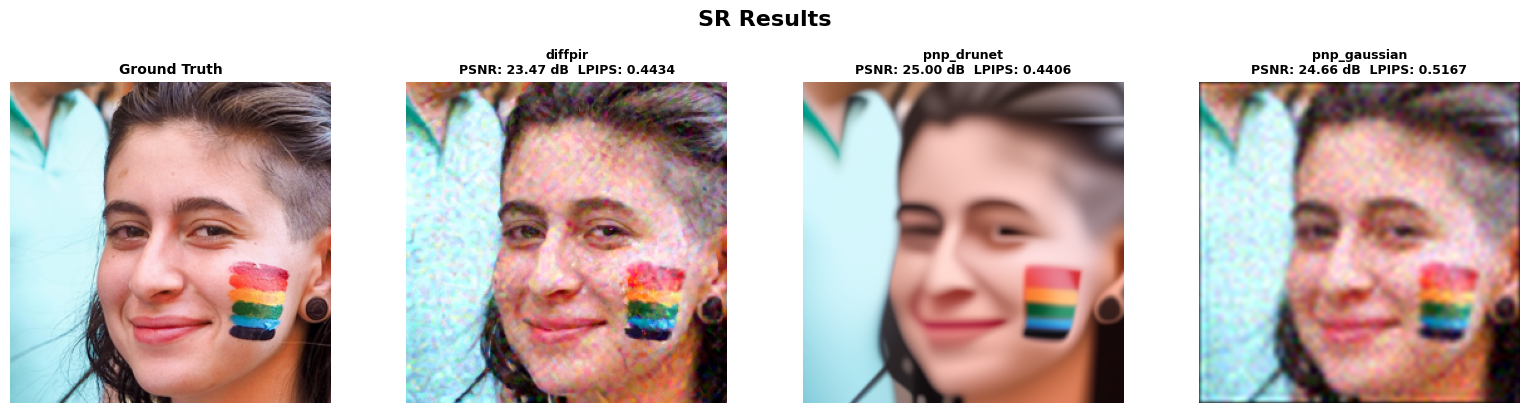

In [ ]:
# Super-resolution comparison
sr_results = compare_task(
    task="sr",
    testset_root="testsets/demo_test",
    methods=[
        "diffpir",
        "dps_y0",
        "dps_yt",
        "pnp_drunet",
        "pnp_gaussian",
    ],
)
plot_metric_bar(sr_results, metric="average_psnr", title="SR: Average PSNR")
show_results(sr_results, action="SR")

Loading dps_y0 from configs\inpaint.yaml
MethodConfig(task='inpaint', generate_mode='DPS_y0', lambda_=0.1, zeta=0.0, sf=1, extra={'name': 'dps_y0', 'seed': 42, 'noise_level_img': 0.0, 'noise_level_model': 0.0, 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'batch_size': 16, 'save_L': True, 'save_E': True, 'output_root': 'outputs', 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'load_mask': False, 'mask_name': 'gt_keep_masks/face/000000.png', 'mask_type': 'random', 'mask_len_range': [128, 129], 'mask_prob_range': [0.5, 0.5]})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[2026-03-14 01:15:06,721][dps_inpaint.69037][INFO] Loading ground-truth image from testsets/demo_test\69037.png
[2026-03-14 01:15:06,731][dps_inpaint.69037][INFO] Generated random mask | len_range=[128, 129] | prob_range=[0.5, 0.5]
[2026-03-14 01:15:06,731][dps_inpaint.69037][INFO] Applying inpainting mask and AWGN 

Loading model from: c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\lpips\weights\v0.1\vgg.pth


DPS Inpaint DPS_y0: 1000it [03:51,  4.32it/s]
[2026-03-14 01:18:58,470][dps_inpaint.69037][INFO] Reverse diffusion finished for 69037
[2026-03-14 01:18:58,520][dps_inpaint.69037][INFO] Results | img=69037 | PSNR=22.125 dB | LPIPS=0.3904
[2026-03-14 01:18:58,520][dps_inpaint.69037][INFO] Saved restored image to outputs\dps_DPS_y0_inpaint\69037_dps_DPS_y0.png
[2026-03-14 01:18:58,530][dps_inpaint.69037][INFO] Saved masked image to outputs\dps_DPS_y0_inpaint\69037_masked.png


Loading dps_yt from configs\inpaint.yaml
MethodConfig(task='inpaint', generate_mode='DPS_yt', lambda_=0.1, zeta=0.0, sf=1, extra={'name': 'dps_yt', 'seed': 42, 'noise_level_img': 0.0, 'noise_level_model': 0.0, 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'batch_size': 16, 'save_L': True, 'save_E': True, 'output_root': 'outputs', 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'load_mask': False, 'mask_name': 'gt_keep_masks/face/000000.png', 'mask_type': 'random', 'mask_len_range': [128, 129], 'mask_prob_range': [0.5, 0.5]})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-14 01:19:01,189][dps_inpaint.69037][INFO] Loading ground-truth image from testsets/demo_test\69037.png
[2026-03-14 01:19:01,197][dps_inpaint.69037][INFO] Generated random mask | len_range=[128, 129] | prob_range=[0.5, 0.5]
[2026-03-14 01:19:01,199][dps_inpaint.69037][INFO] Applying inpainting mask and AWGN (σ=0.0000)
[2026-03-14 01:19:01,212][dps_inpaint.69037][INFO] Starting DPS reverse diffusion (1000 steps)


Loading model from: c:\Users\romai\AppData\Local\Programs\Python\Python311\Lib\site-packages\lpips\weights\v0.1\vgg.pth


DPS Inpaint DPS_yt: 1000it [02:17,  7.25it/s]
[2026-03-14 01:21:19,149][dps_inpaint.69037][INFO] Reverse diffusion finished for 69037
[2026-03-14 01:21:19,182][dps_inpaint.69037][INFO] Results | img=69037 | PSNR=18.609 dB | LPIPS=0.5378
[2026-03-14 01:21:19,197][dps_inpaint.69037][INFO] Saved restored image to outputs\dps_DPS_yt_inpaint\69037_dps_DPS_yt.png
[2026-03-14 01:21:19,197][dps_inpaint.69037][INFO] Saved masked image to outputs\dps_DPS_yt_inpaint\69037_masked.png


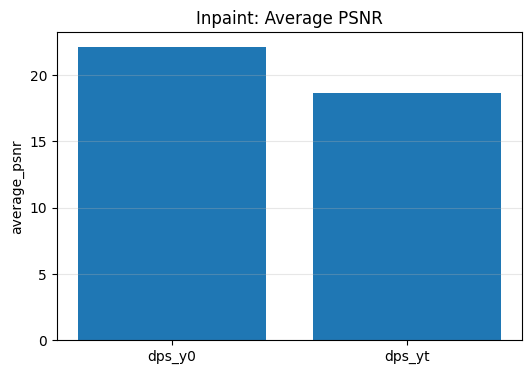

0.0 1.0


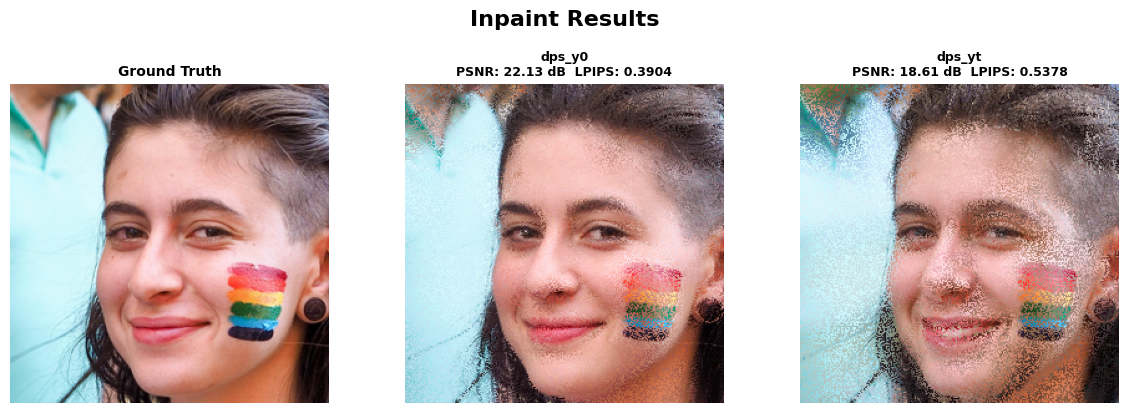

In [ ]:
# Inpainting comparison
inpaint_results = compare_task(
    task="inpaint",
    testset_root="testsets/demo_test",
    methods=[
        "diffpir",
        "dps_y0",
        "dps_yt",
        "pnp_diffbir",
        "pnp_drunet",
        "pnp_gaussian",
    ],
)
plot_metric_bar(inpaint_results, metric="average_psnr", title="Inpaint: Average PSNR")
show_results(inpaint_results, action="Inpaint")